# 0. Load imports

In [16]:
import os

# 1. Load the data

In [17]:
from datasets import load_dataset

ROOT = os.path.join(os.getcwd(), "..")
DATA = os.path.join(ROOT, "data")
PROCESSED = os.path.join(DATA, "processed")
SUMMARY = os.path.join(PROCESSED, "summary")

CNN = os.path.join(SUMMARY, "CNN_DM")
NS = os.path.join(SUMMARY, "NS")

dataset = load_dataset("csv", data_files={
    "test": os.path.join(CNN, "test.csv"),
})

# temporaryily limit each split
seed=42

test_articles, test_references = dataset["test"]["article"], dataset["test"]["summary"]

# 3. Baseline (Lead-2)

In [18]:
from nltk.tokenize import sent_tokenize

def lead_n(article, n):
    sentences = sent_tokenize(article)
    return ' '.join(sentences[:n])

lead2_pred = [lead_n(x, 2) for x in test_articles]

# 4. Compute ROUGE scores

In [19]:
import evaluate

rouge = evaluate.load("rouge")

lead2_scores = rouge.compute(
    predictions=lead2_pred,
    references=list(test_references),
    use_stemmer=True
)

print("Lead-2 Baseline ROUGE Scores")
for metric, score in lead2_scores.items():
    print(f"{metric}: {round(score, 3)}")

Lead-2 Baseline ROUGE Scores
rouge1: 0.38
rouge2: 0.156
rougeL: 0.236
rougeLsum: 0.236


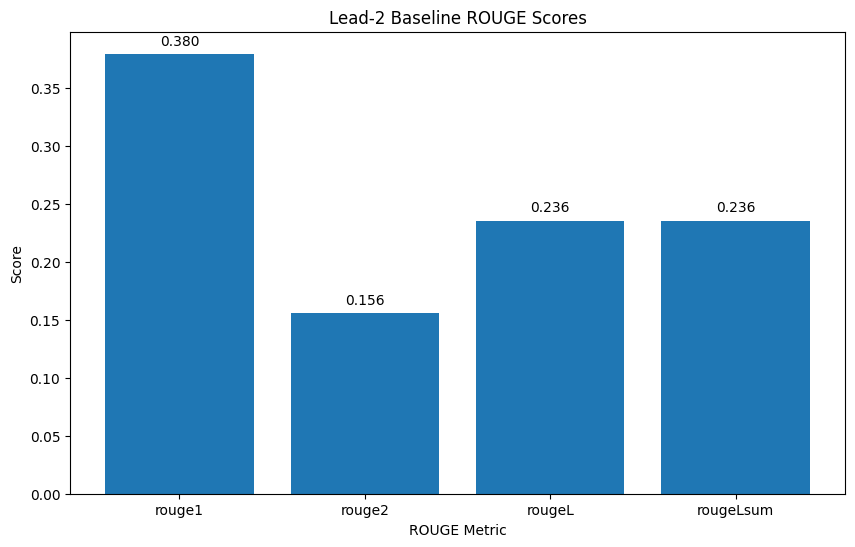

In [20]:
import matplotlib.pyplot as plt

metrics, values = list(lead2_scores.keys()), list(lead2_scores.values())

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values)

plt.xlabel('ROUGE Metric')
plt.ylabel('Score')
plt.title('Lead-2 Baseline ROUGE Scores')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.005, f"{yval:.3f}", ha="center", va="bottom")

plt.show()